# HW1：从零开始构建三层神经网络分类器 —— EuroSAT 地表覆盖图像分类

> **核心约束**：不使用 PyTorch / TensorFlow / JAX 等自动微分框架，仅使用 NumPy 手工实现前向传播、反向传播与参数更新。

---

In [1]:
import numpy as np
import os
import glob
import pickle
import matplotlib.pyplot as plt
from PIL import Image                       
from collections import Counter
from itertools import product as iter_product  

%matplotlib inline
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)


---
## 一、数据加载与预处理模块

EuroSAT_RGB 数据集包含 10 个地表覆盖类别，每个类别包含若干 64×64 RGB 卫星图像（.jpg 格式）。

**预处理步骤**：
1. 遍历各类别文件夹，读取图像并 resize 到 64×64（保持一致）
2. 将像素值归一化到 [0, 1]
3. 将图像展平为一维向量（64×64×3 = 12288 维）
4. 按 7:1.5:1.5 比例划分训练集、验证集和测试集

In [5]:
class EuroSATDataLoader:
    # 10 个类别名称（与文件夹名称对应）
    CLASS_NAMES = [
        'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
        'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
        'River', 'SeaLake'
    ]
    
    def __init__(self, data_dir, img_size=64, max_per_class=None):
        self.data_dir = data_dir
        self.img_size = img_size
        self.max_per_class = max_per_class # 每类最大加载数量，None 表示全部加载
    
    def load_data(self):
        """加载全部图像数据
        
        返回:
            X: shape (N, 12288) 的特征矩阵，像素值归一化到 [0, 1]
            y: shape (N,) 的标签数组，值为 0~9 对应 10 个类别
        """
        images = []
        labels = []
        
        for class_idx, class_name in enumerate(self.CLASS_NAMES):
            class_dir = os.path.join(self.data_dir, class_name)
            if not os.path.isdir(class_dir):
                print(f"警告: 类别文件夹 {class_dir} 不存在，跳过")
                continue
            
            # 获取该类别下所有 jpg 文件
            img_paths = sorted(glob.glob(os.path.join(class_dir, '*.jpg'))) 
            if self.max_per_class is not None:
                img_paths = img_paths[:self.max_per_class]
            
            for img_path in img_paths:
                try:
                    # 读取图像并 resize
                    img = Image.open(img_path).convert('RGB')
                    # img = img.resize((self.img_size, self.img_size)) 
                    # 转为 numpy 数组并归一化到 [0, 1]
                    img_array = np.array(img, dtype=np.float64) / 255.0
                    # 展平为一维向量: (64, 64, 3) -> (12288,)
                    images.append(img_array.flatten())
                    labels.append(class_idx)
                except Exception as e:
                    print(f"读取 {img_path} 失败: {e}")
        
        X = np.array(images)
        y = np.array(labels)
        print(f"数据加载完成: {X.shape[0]} 张图像, 特征维度 {X.shape[1]}")
        print(f"各类别数量: {dict(Counter(y))}")
        return X, y
    
    @staticmethod
    def train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
        """按比例划分训练集、验证集、测试集（分层抽样，保证各类别比例一致）
        
        参数:
            X: 特征矩阵
            y: 标签数组
            train_ratio: 训练集比例
            val_ratio: 验证集比例 (测试集比例 = 1 - train - val)
            seed: 随机种子
        
        返回:
            (X_train, y_train), (X_val, y_val), (X_test, y_test)
        """
        np.random.seed(seed)
        
        classes = np.unique(y)
        train_idx, val_idx, test_idx = [], [], []
        
        for c in classes:
            # 获取当前类别的所有样本索引
            idx = np.where(y == c)[0]
            np.random.shuffle(idx)
            
            n = len(idx)
            n_train = int(n * train_ratio)
            n_val = int(n * val_ratio)
            
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:n_train + n_val])
            test_idx.extend(idx[n_train + n_val:])
        
        # 打乱顺序
        np.random.shuffle(train_idx)
        np.random.shuffle(val_idx)
        np.random.shuffle(test_idx)
        
        print(f"数据集划分: 训练 {len(train_idx)} | 验证 {len(val_idx)} | 测试 {len(test_idx)}")
        return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])

In [6]:
# 本地的 EuroSAT_RGB 文件夹
data_dir = './EuroSAT_RGB'

loader = EuroSATDataLoader(data_dir, img_size=64)
X, y = loader.load_data()

# 划分数据集: 70% 训练, 15% 验证, 15% 测试
(X_train, y_train), (X_val, y_val), (X_test, y_test) = \
    EuroSATDataLoader.train_val_test_split(X, y)

# 数据标准化：用训练集的均值和标准差对所有数据进行 z-score 标准化
# 这有助于加速训练收敛
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8   # 加小量防止除零

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

print(f"\n标准化后训练集统计: mean={X_train.mean():.4f}, std={X_train.std():.4f}")
print(f"特征维度: {X_train.shape[1]}")

数据加载完成: 27000 张图像, 特征维度 12288
各类别数量: {np.int64(0): 3000, np.int64(1): 3000, np.int64(2): 3000, np.int64(3): 2500, np.int64(4): 2500, np.int64(5): 2000, np.int64(6): 2500, np.int64(7): 3000, np.int64(8): 2500, np.int64(9): 3000}
数据集划分: 训练 18900 | 验证 4050 | 测试 4050

标准化后训练集统计: mean=0.0000, std=1.0000
特征维度: 12288


---
## 二、模型定义模块

### 网络结构

```
输入层 (12288) → 隐藏层1 (hidden_dim) → 激活函数 → 隐藏层2 (hidden_dim) → 激活函数 → 输出层 (10) → Softmax
```

### 关键设计
- **激活函数**：支持 ReLU、Sigmoid、Tanh 三种，可自由切换
- **权重初始化**：He 初始化 (ReLU) 或 Xavier 初始化 (Sigmoid/Tanh)
- **反向传播**：手动实现链式法则，逐层计算梯度

In [7]:
class ReLU:
    """ReLU 激活函数: f(x) = max(0, x)"""
    
    def forward(self, x):
        """前向传播，同时缓存输入用于反向传播"""
        self.mask = (x > 0).astype(np.float64)  # 记录哪些位置 > 0
        return x * self.mask
    
    def backward(self, d_out):
        """反向传播: ReLU 的导数在 x>0 时为 1，x<=0 时为 0"""
        return d_out * self.mask


class Sigmoid:
    """Sigmoid 激活函数: f(x) = 1 / (1 + exp(-x))"""
    
    def forward(self, x):
        # 数值稳定版本：避免 exp 溢出
        self.out = np.where(x >= 0,
                            1.0 / (1.0 + np.exp(-x)),
                            np.exp(x) / (1.0 + np.exp(x)))
        return self.out
    
    def backward(self, d_out):
        """Sigmoid 的导数: f'(x) = f(x) * (1 - f(x))"""
        return d_out * self.out * (1.0 - self.out)


class Tanh:
    """Tanh 激活函数: f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))"""
    
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out
    
    def backward(self, d_out):
        """Tanh 的导数: f'(x) = 1 - f(x)^2"""
        return d_out * (1.0 - self.out ** 2)


# 激活函数工厂：根据名称创建对应的激活函数对象
def get_activation(name):
    """根据名称返回激活函数实例
    
    参数:
        name: 'relu', 'sigmoid', 或 'tanh'
    """
    activations = {
        'relu': ReLU,
        'sigmoid': Sigmoid,
        'tanh': Tanh
    }
    if name.lower() not in activations:
        raise ValueError(f"不支持的激活函数: {name}，可选: {list(activations.keys())}")
    return activations[name.lower()]()

print("激活函数模块定义完成 ✓")

激活函数模块定义完成 ✓


In [8]:
class SoftmaxCrossEntropyLoss:
    """Softmax + 交叉熵损失函数
    
    将 Softmax 和 Cross-Entropy 合并计算，数值更稳定。
    
    前向:
        1. 对 logits 做 softmax 得到概率分布 p
        2. 计算交叉熵: L = -log(p[正确类别])
        
    反向:
        梯度 = p - one_hot(y)  
    """
    
    def forward(self, logits, y):
        """
        参数:
            logits: shape (N, C) 未经 softmax 的网络输出
            y: shape (N,) 真实类别标签 (0~C-1)
        
        返回:
            loss: 标量，平均交叉熵损失
        """
        N = logits.shape[0]
        
        # 数值稳定的 softmax：减去每行最大值防止 exp 溢出
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        self.probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        
        # 交叉熵: -log(p_正确类别)
        # 加 1e-12 防止 log(0)
        correct_log_probs = -np.log(self.probs[np.arange(N), y] + 1e-12)
        loss = correct_log_probs.mean()
        
        # 缓存用于反向传播
        self.y = y
        self.N = N
        
        return loss
    
    def backward(self):
        """计算 loss 对 logits 的梯度
        
        返回:
            d_logits: shape (N, C), 梯度 = (softmax概率 - one_hot标签) / N
        """
        d_logits = self.probs.copy()
        d_logits[np.arange(self.N), self.y] -= 1.0
        d_logits /= self.N   # 取平均
        return d_logits

print("损失函数模块定义完成 ✓")

损失函数模块定义完成 ✓


In [9]:
class ThreeLayerMLP:
    """三层全连接神经网络 (MLP)
    
    结构: Input → Linear1 → Activation → Linear2 → Activation → Linear3 → Softmax
    
    参数:
        input_dim:  输入特征维度 (EuroSAT: 64*64*3 = 12288)
        hidden_dim: 隐藏层神经元数量 (两个隐藏层共用)
        num_classes: 输出类别数 (EuroSAT: 10)
        activation: 激活函数名称 ('relu', 'sigmoid', 'tanh')
    """
    
    def __init__(self, input_dim, hidden_dim, num_classes=10, activation='relu'):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.activation_name = activation
        
        # 创建两个激活函数实例（各层独立，因为需要各自缓存前向传播的中间结果）
        self.act1 = get_activation(activation)
        self.act2 = get_activation(activation)
        
        # ---- 权重初始化 ----
        # 根据激活函数选择初始化策略
        if activation == 'relu':
            # He 初始化: std = sqrt(2 / fan_in)
            # 适合 ReLU，因为 ReLU 会 "杀死" 一半的神经元
            self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
            self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
            self.W3 = np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / hidden_dim)
        else:
            # Xavier 初始化: std = sqrt(2 / (fan_in + fan_out))
            # 适合 Sigmoid 和 Tanh
            self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / (input_dim + hidden_dim))
            self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + hidden_dim))
            self.W3 = np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / (hidden_dim + num_classes))
        
        # 偏置初始化为 0
        self.b1 = np.zeros(hidden_dim)
        self.b2 = np.zeros(hidden_dim)
        self.b3 = np.zeros(num_classes)
        
        # 梯度缓存（反向传播后填充）
        self.grads = {}
    
    def forward(self, X):
        """前向传播
        
        参数:
            X: shape (N, input_dim) 输入数据
        
        返回:
            logits: shape (N, num_classes) 未经 softmax 的输出
        """
        # 缓存各层输入，供反向传播使用
        self.X = X
        
        # 第一层: 线性变换 + 激活
        self.z1 = X @ self.W1 + self.b1              # (N, hidden_dim)
        self.a1 = self.act1.forward(self.z1)          # (N, hidden_dim)
        
        # 第二层: 线性变换 + 激活
        self.z2 = self.a1 @ self.W2 + self.b2         # (N, hidden_dim)
        self.a2 = self.act2.forward(self.z2)           # (N, hidden_dim)
        
        # 第三层 (输出层): 线性变换 (不加激活，后面接 Softmax)
        self.logits = self.a2 @ self.W3 + self.b3     # (N, num_classes)
        
        return self.logits
    
    def backward(self, d_logits):
        """反向传播：根据链式法则逐层计算梯度
        
        参数:
            d_logits: shape (N, num_classes) loss 对 logits 的梯度
        """
        N = self.X.shape[0]
        
        # ---- 第三层 (输出层) 的梯度 ----
        # dL/dW3 = a2^T @ d_logits
        self.grads['W3'] = self.a2.T @ d_logits        # (hidden_dim, num_classes)
        self.grads['b3'] = d_logits.sum(axis=0)         # (num_classes,)
        
        # 传递到第二层的梯度
        d_a2 = d_logits @ self.W3.T                     # (N, hidden_dim)
        
        # ---- 第二层隐藏层的梯度 ----
        # 先通过激活函数的反向传播
        d_z2 = self.act2.backward(d_a2)                 # (N, hidden_dim)
        self.grads['W2'] = self.a1.T @ d_z2             # (hidden_dim, hidden_dim)
        self.grads['b2'] = d_z2.sum(axis=0)             # (hidden_dim,)
        
        # 传递到第一层的梯度
        d_a1 = d_z2 @ self.W2.T                         # (N, hidden_dim)
        
        # ---- 第一层隐藏层的梯度 ----
        d_z1 = self.act1.backward(d_a1)                 # (N, hidden_dim)
        self.grads['W1'] = self.X.T @ d_z1              # (input_dim, hidden_dim)
        self.grads['b1'] = d_z1.sum(axis=0)             # (hidden_dim,)
    
    def predict(self, X):
        """预测类别
        
        参数:
            X: shape (N, input_dim)
        返回:
            predictions: shape (N,) 预测的类别索引
        """
        logits = self.forward(X)
        return np.argmax(logits, axis=1)
    
    def save_weights(self, filepath):
        """保存模型权重到文件"""
        weights = {
            'W1': self.W1, 'b1': self.b1,
            'W2': self.W2, 'b2': self.b2,
            'W3': self.W3, 'b3': self.b3,
            'config': {
                'input_dim': self.input_dim,
                'hidden_dim': self.hidden_dim,
                'num_classes': self.num_classes,
                'activation': self.activation_name
            }
        }
        with open(filepath, 'wb') as f:
            pickle.dump(weights, f)
        print(f"模型权重已保存到 {filepath}")
    
    @classmethod
    def load_weights(cls, filepath):
        """从文件加载模型权重"""
        with open(filepath, 'rb') as f:
            weights = pickle.load(f)
        
        config = weights['config']
        model = cls(config['input_dim'], config['hidden_dim'],
                    config['num_classes'], config['activation'])
        model.W1, model.b1 = weights['W1'], weights['b1']
        model.W2, model.b2 = weights['W2'], weights['b2']
        model.W3, model.b3 = weights['W3'], weights['b3']
        print(f"模型权重已从 {filepath} 加载")
        return model

print("三层 MLP 模型定义完成 ✓")
print(f"  - 支持激活函数: relu, sigmoid, tanh")
print(f"  - 支持自定义隐藏层大小")
print(f"  - 支持权重保存与加载")

三层 MLP 模型定义完成 ✓
  - 支持激活函数: relu, sigmoid, tanh
  - 支持自定义隐藏层大小
  - 支持权重保存与加载


---
## 三、训练模块

包含以下组件：
- **SGD 优化器**：支持 L2 正则化 (Weight Decay)
- **学习率衰减**：支持 Step Decay 和 Cosine Annealing
- **训练循环**：Mini-batch 训练，自动保存验证集上的最佳模型

In [10]:
class SGDOptimizer:
    """随机梯度下降优化器
    
    参数:
        model: ThreeLayerMLP 实例
        lr: 初始学习率
        weight_decay: L2 正则化强度 (即权重衰减系数)
    """
    
    def __init__(self, model, lr=0.01, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay
    
    def step(self):
        """执行一步参数更新
        
        更新规则: W = W - lr * (dW + weight_decay * W)
                  b = b - lr * db  (偏置不做正则化)
        """
        for name in ['W1', 'W2', 'W3']:
            W = getattr(self.model, name)
            dW = self.model.grads[name]
            # L2 正则化：梯度中加入 weight_decay * W
            W -= self.lr * (dW + self.weight_decay * W)
        
        for name in ['b1', 'b2', 'b3']:
            b = getattr(self.model, name)
            db = self.model.grads[name]
            b -= self.lr * db     # 偏置不正则化


class LRScheduler:
    """学习率衰减调度器
    
    支持两种策略:
        - 'step': 每隔 step_size 个 epoch，学习率乘以 gamma
        - 'cosine': 余弦退火，从初始学习率平滑衰减到 0
    """
    
    def __init__(self, optimizer, strategy='step', step_size=30, gamma=0.5, total_epochs=100):
        self.optimizer = optimizer
        self.strategy = strategy
        self.initial_lr = optimizer.lr
        self.step_size = step_size
        self.gamma = gamma
        self.total_epochs = total_epochs
    
    def step(self, epoch):
        """根据当前 epoch 更新学习率"""
        if self.strategy == 'step':
            # 阶梯衰减: 每 step_size 个 epoch 乘以 gamma
            factor = self.gamma ** (epoch // self.step_size)
            self.optimizer.lr = self.initial_lr * factor
        elif self.strategy == 'cosine':
            # 余弦退火: lr = 0.5 * lr_init * (1 + cos(pi * epoch / total))
            self.optimizer.lr = 0.5 * self.initial_lr * \
                (1 + np.cos(np.pi * epoch / self.total_epochs))
        
        return self.optimizer.lr

print("优化器与学习率调度器定义完成 ✓")

优化器与学习率调度器定义完成 ✓


In [11]:
class Trainer:
    """训练器：管理整个训练流程
    
    功能:
        - Mini-batch 训练
        - 每个 epoch 在验证集上评估
        - 自动保存验证准确率最高的模型
        - 记录训练/验证的 loss 和 accuracy 曲线
    """
    
    def __init__(self, model, optimizer, scheduler, loss_fn, save_path='best_model.pkl'):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.loss_fn = loss_fn
        self.save_path = save_path
        
        # 训练历史记录
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
            'lr': []
        }
    
    def _compute_accuracy(self, X, y, batch_size=512):
        """计算准确率 (分批处理避免内存溢出)"""
        correct = 0
        total = len(y)
        for i in range(0, total, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            preds = self.model.predict(X_batch)
            correct += (preds == y_batch).sum()
        return correct / total
    
    def _compute_loss(self, X, y, batch_size=512):
        """计算平均损失 (分批处理)"""
        total_loss = 0.0
        n_batches = 0
        for i in range(0, len(y), batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            logits = self.model.forward(X_batch)
            loss = self.loss_fn.forward(logits, y_batch)
            total_loss += loss
            n_batches += 1
        return total_loss / n_batches
    
    def train(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=128, verbose=True):
        """执行训练
        
        参数:
            X_train, y_train: 训练数据
            X_val, y_val: 验证数据
            epochs: 训练轮数
            batch_size: 小批量大小
            verbose: 是否打印训练信息
        """
        best_val_acc = 0.0
        N = X_train.shape[0]
        
        for epoch in range(epochs):
            # ---- 更新学习率 ----
            current_lr = self.scheduler.step(epoch)
            
            # ---- 打乱训练数据 ----
            perm = np.random.permutation(N)
            X_shuffled = X_train[perm]
            y_shuffled = y_train[perm]
            
            # ---- Mini-batch 训练 ----
            epoch_loss = 0.0
            n_batches = 0
            
            for i in range(0, N, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # 前向传播
                logits = self.model.forward(X_batch)
                
                # 计算损失
                loss = self.loss_fn.forward(logits, y_batch)
                
                # L2 正则化损失（加到总损失中用于监控）
                l2_loss = 0.0
                if self.optimizer.weight_decay > 0:
                    for name in ['W1', 'W2', 'W3']:
                        W = getattr(self.model, name)
                        l2_loss += 0.5 * self.optimizer.weight_decay * np.sum(W ** 2)
                
                epoch_loss += loss + l2_loss
                n_batches += 1
                
                # 反向传播
                d_logits = self.loss_fn.backward()
                self.model.backward(d_logits)
                
                # 参数更新
                self.optimizer.step()
            
            # ---- Epoch 结束，记录指标 ----
            avg_train_loss = epoch_loss / n_batches
            val_loss = self._compute_loss(X_val, y_val)
            train_acc = self._compute_accuracy(X_train, y_train)
            val_acc = self._compute_accuracy(X_val, y_val)
            
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['lr'].append(current_lr)
            
            # ---- 保存最佳模型 ----
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                self.model.save_weights(self.save_path)
                marker = ' ★ 新最佳!'
            else:
                marker = ''
            
            # ---- 打印训练信息 ----
            if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch+1:3d}/{epochs} | "
                      f"LR: {current_lr:.6f} | "
                      f"Train Loss: {avg_train_loss:.4f} | "
                      f"Val Loss: {val_loss:.4f} | "
                      f"Train Acc: {train_acc:.4f} | "
                      f"Val Acc: {val_acc:.4f}{marker}")
        
        print(f"\n训练完成！最佳验证准确率: {best_val_acc:.4f}")
        return self.history

print("训练器定义完成 ✓")

训练器定义完成 ✓


In [ ]:
# 超参数设置
HIDDEN_DIM = 256          # 隐藏层大小
ACTIVATION = 'relu'       # 激活函数
LEARNING_RATE = 0.01      # 初始学习率
WEIGHT_DECAY = 1e-4       # L2 正则化强度
EPOCHS = 80               # 训练轮数
BATCH_SIZE = 128          # 小批量大小
LR_DECAY = 'step'         # 学习率衰减策略
STEP_SIZE = 25            # 学习率衰减步长
GAMMA = 0.5               # 学习率衰减系数

print("=" * 60)
print(f"训练配置:")
print(f"  隐藏层大小: {HIDDEN_DIM}")
print(f"  激活函数:   {ACTIVATION}")
print(f"  学习率:     {LEARNING_RATE}")
print(f"  正则化:     {WEIGHT_DECAY}")
print(f"  训练轮数:   {EPOCHS}")
print(f"  批量大小:   {BATCH_SIZE}")
print("=" * 60)

# 创建模型
model = ThreeLayerMLP(
    input_dim=X_train.shape[1],
    hidden_dim=HIDDEN_DIM,
    num_classes=10,
    activation=ACTIVATION
)

# 创建损失函数
loss_fn = SoftmaxCrossEntropyLoss()

# 创建优化器
optimizer = SGDOptimizer(model, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 创建学习率调度器
scheduler = LRScheduler(optimizer, strategy=LR_DECAY,
                        step_size=STEP_SIZE, gamma=GAMMA, total_epochs=EPOCHS)

# 创建训练器并执行训练
trainer = Trainer(model, optimizer, scheduler, loss_fn, save_path='best_model.pkl')
history = trainer.train(X_train, y_train, X_val, y_val,
                        epochs=EPOCHS, batch_size=BATCH_SIZE)

训练配置:
  隐藏层大小: 256
  激活函数:   relu
  学习率:     0.01
  正则化:     0.0001
  训练轮数:   80
  批量大小:   128
模型权重已保存到 best_model.pkl
Epoch   1/80 | LR: 0.010000 | Train Loss: 1.8934 | Val Loss: 1.3295 | Train Acc: 0.5589 | Val Acc: 0.5193 ★ 新最佳!
模型权重已保存到 best_model.pkl
模型权重已保存到 best_model.pkl
模型权重已保存到 best_model.pkl
模型权重已保存到 best_model.pkl
Epoch   6/80 | LR: 0.010000 | Train Loss: 0.9201 | Val Loss: 1.1193 | Train Acc: 0.7334 | Val Acc: 0.5998 ★ 新最佳!
模型权重已保存到 best_model.pkl
模型权重已保存到 best_model.pkl
模型权重已保存到 best_model.pkl
Epoch  11/80 | LR: 0.010000 | Train Loss: 0.7100 | Val Loss: 1.0826 | Train Acc: 0.8125 | Val Acc: 0.6319 ★ 新最佳!
模型权重已保存到 best_model.pkl
Epoch  16/80 | LR: 0.010000 | Train Loss: 0.5702 | Val Loss: 1.0660 | Train Acc: 0.8594 | Val Acc: 0.6393 ★ 新最佳!
模型权重已保存到 best_model.pkl
Epoch  21/80 | LR: 0.010000 | Train Loss: 0.4867 | Val Loss: 1.1556 | Train Acc: 0.8747 | Val Acc: 0.6264
模型权重已保存到 best_model.pkl
Epoch  26/80 | LR: 0.005000 | Train Loss: 0.3573 | Val Loss: 1.1024 | Train Acc: 0.

---
## 四、训练过程可视化

绘制训练集和验证集上的 Loss 曲线、Accuracy 曲线以及学习率变化曲线。

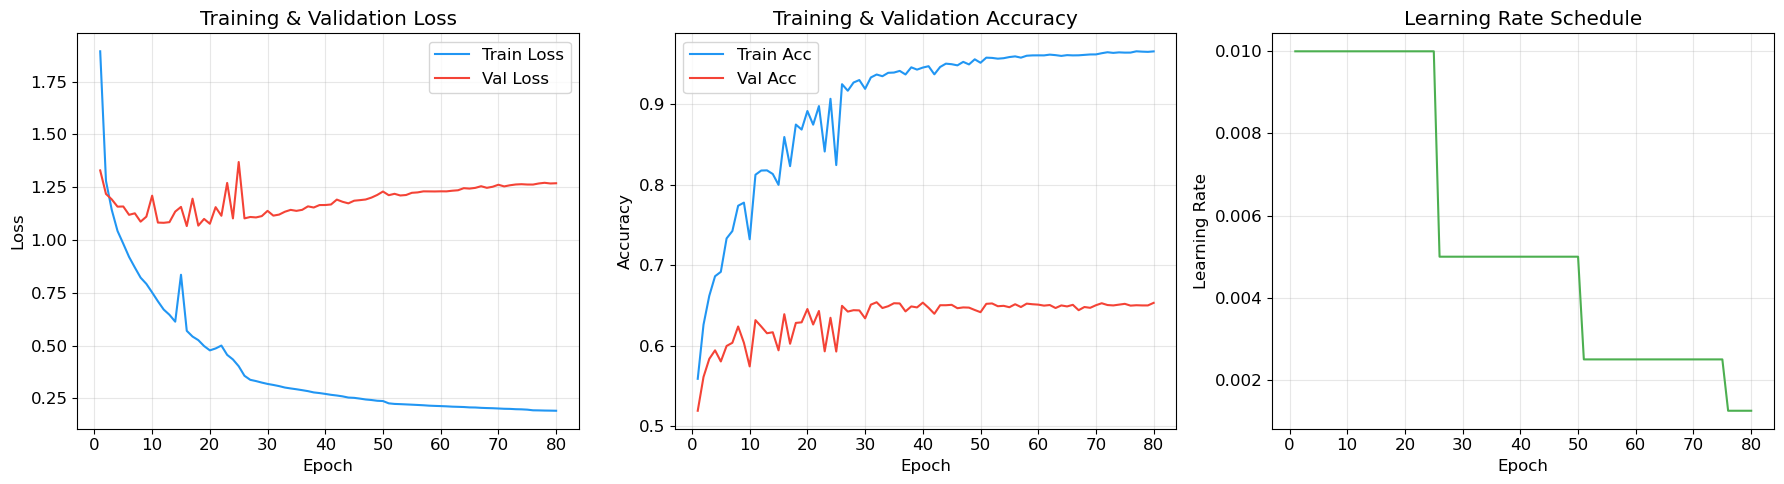

训练曲线已保存为 training_curves.png


In [ ]:
def plot_training_curves(history):
    """绘制训练过程的各项指标曲线"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    # ---- Loss 曲线 ----
    axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#2196F3')
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='#F44336')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # ---- Accuracy 曲线 ----
    axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='#2196F3')
    axes[1].plot(epochs_range, history['val_acc'], label='Val Acc', color='#F44336')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # ---- 学习率曲线 ----
    axes[2].plot(epochs_range, history['lr'], color='#4CAF50')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("训练曲线已保存为 training_curves.png")

plot_training_curves(history)

---
## 五、测试评估模块

加载训练好的最佳模型权重，在独立测试集上计算分类准确率，并打印混淆矩阵。

In [13]:
# 超参数设置
HIDDEN_DIM = 256          # 隐藏层大小
ACTIVATION = 'relu'       # 激活函数
LEARNING_RATE = 0.01      # 初始学习率
WEIGHT_DECAY = 1e-4       # L2 正则化强度
EPOCHS = 80               # 训练轮数
BATCH_SIZE = 128          # 小批量大小
LR_DECAY = 'step'         # 学习率衰减策略
STEP_SIZE = 25            # 学习率衰减步长
GAMMA = 0.5               # 学习率衰减系数

print("=" * 60)
print(f"训练配置:")
print(f"  隐藏层大小: {HIDDEN_DIM}")
print(f"  激活函数:   {ACTIVATION}")
print(f"  学习率:     {LEARNING_RATE}")
print(f"  正则化:     {WEIGHT_DECAY}")
print(f"  训练轮数:   {EPOCHS}")
print(f"  批量大小:   {BATCH_SIZE}")
print("=" * 60)

# 创建模型
model = ThreeLayerMLP(
    input_dim=X_train.shape[1],
    hidden_dim=HIDDEN_DIM,
    num_classes=10,
    activation=ACTIVATION
)

# 创建损失函数
loss_fn = SoftmaxCrossEntropyLoss()

# 创建优化器
optimizer = SGDOptimizer(model, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 创建学习率调度器
scheduler = LRScheduler(optimizer, strategy=LR_DECAY,
                        step_size=STEP_SIZE, gamma=GAMMA, total_epochs=EPOCHS)

训练配置:
  隐藏层大小: 256
  激活函数:   relu
  学习率:     0.01
  正则化:     0.0001
  训练轮数:   80
  批量大小:   128


模型权重已从 best_model.pkl 加载

测试集准确率: 0.6521 (2641/4050)


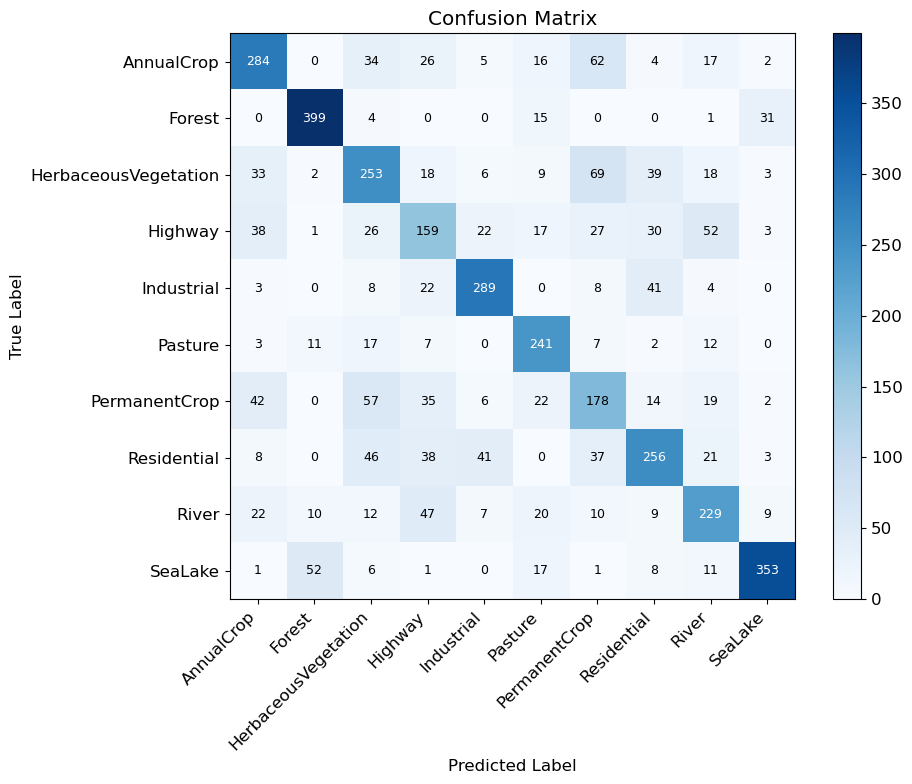

混淆矩阵已保存为 confusion_matrix.png

各类别准确率:
  AnnualCrop               : 0.6311 (284/450)
  Forest                   : 0.8867 (399/450)
  HerbaceousVegetation     : 0.5622 (253/450)
  Highway                  : 0.4240 (159/375)
  Industrial               : 0.7707 (289/375)
  Pasture                  : 0.8033 (241/300)
  PermanentCrop            : 0.4747 (178/375)
  Residential              : 0.5689 (256/450)
  River                    : 0.6107 (229/375)
  SeaLake                  : 0.7844 (353/450)


In [14]:
def compute_confusion_matrix(y_true, y_pred, num_classes):
    """计算混淆矩阵
    
    参数:
        y_true: 真实标签
        y_pred: 预测标签
        num_classes: 类别数
    
    返回:
        cm: shape (num_classes, num_classes) 的混淆矩阵
            cm[i][j] = 真实类别为 i 但被预测为 j 的样本数
    """
    cm = np.zeros((num_classes, num_classes), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm


def plot_confusion_matrix(cm, class_names):
    """可视化混淆矩阵"""
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           ylabel='True Label',
           xlabel='Predicted Label',
           title='Confusion Matrix')
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # 在每个格子中写入数值
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=9)
    
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("混淆矩阵已保存为 confusion_matrix.png")


# ---- 加载最佳模型并测试 ----
best_model = ThreeLayerMLP.load_weights('best_model.pkl')
y_pred = best_model.predict(X_test)

# 计算测试准确率
test_acc = (y_pred == y_test).mean()
print(f"\n测试集准确率: {test_acc:.4f} ({(y_pred == y_test).sum()}/{len(y_test)})")

# 计算并可视化混淆矩阵
cm = compute_confusion_matrix(y_test, y_pred, num_classes=10)
plot_confusion_matrix(cm, EuroSATDataLoader.CLASS_NAMES)

# 打印每个类别的准确率
print("\n各类别准确率:")
for i, name in enumerate(EuroSATDataLoader.CLASS_NAMES):
    if cm[i].sum() > 0:
        acc = cm[i][i] / cm[i].sum()
        print(f"  {name:25s}: {acc:.4f} ({cm[i][i]}/{cm[i].sum()})")

---
## 六、权重可视化与空间模式观察

将第一层隐藏层的权重矩阵 W1（shape: 12288 × hidden_dim）的每一列恢复为 64×64×3 的图像格式进行可视化。

观察这些权重是否捕获了特定的空间纹理或颜色模式，例如：
- 河流类别：是否有蓝色调或线状纹理？
- 森林类别：是否有绿色调或团块纹理？

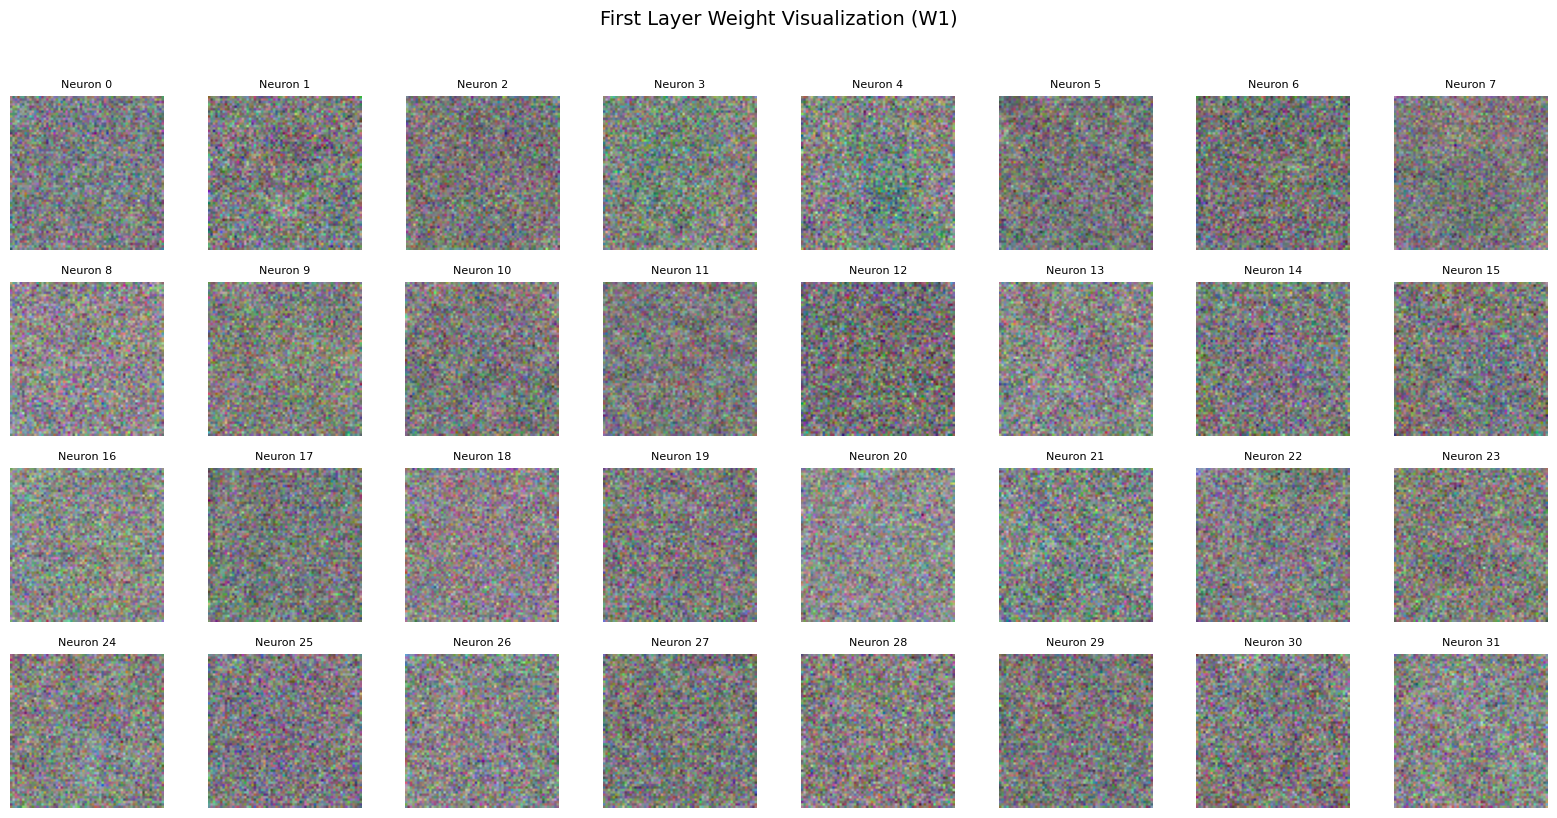

权重可视化图已保存为 weight_visualization.png


In [ ]:
def visualize_weights(model, n_show=32, img_size=64):
    """可视化第一层权重
    
    将 W1 的每一列（对应一个隐藏神经元）恢复为图像形状，
    并归一化到 [0, 1] 进行可视化。
    
    参数:
        model: 训练好的 ThreeLayerMLP
        n_show: 显示的神经元数量
        img_size: 图像尺寸
    """
    W1 = model.W1   # shape: (12288, hidden_dim)
    
    n_show = min(n_show, W1.shape[1])
    n_cols = 8
    n_rows = (n_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
    
    for i in range(n_rows * n_cols):
        ax = axes[i // n_cols, i % n_cols] if n_rows > 1 else axes[i % n_cols]
        
        if i < n_show:
            # 取出第 i 个神经元的权重并恢复为图像形状
            w = W1[:, i].reshape(img_size, img_size, 3)
            
            # 归一化到 [0, 1] 以便可视化
            w_min, w_max = w.min(), w.max()
            if w_max - w_min > 0:
                w = (w - w_min) / (w_max - w_min)
            
            ax.imshow(w)
            ax.set_title(f'Neuron {i}', fontsize=8)
        
        ax.axis('off')
    
    plt.suptitle('First Layer Weight Visualization (W1)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('weight_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("权重可视化图已保存为 weight_visualization.png")

# 使用最佳模型进行权重可视化
visualize_weights(best_model, n_show=32)



---
## 七、错例分析 (Error Analysis)

从测试集中挑选分类错误的样本，可视化原始图像，并分析误分类的可能原因。

测试集中共 1409 个分类错误（共 4050 个样本）


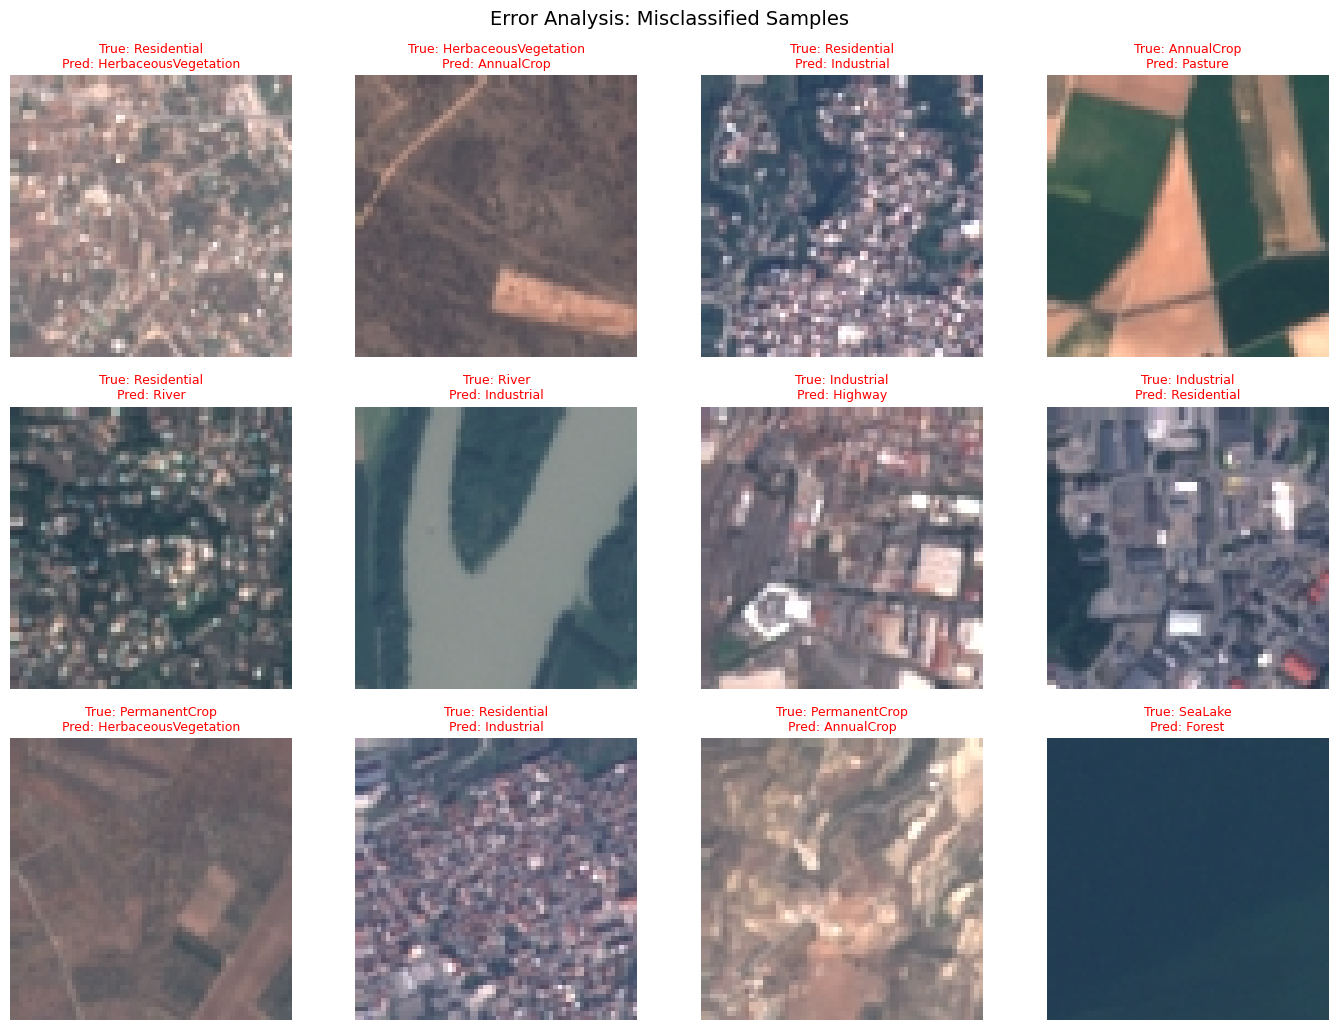

错例分析图已保存为 error_analysis.png


In [ ]:
def error_analysis(X_test, y_test, y_pred, class_names, mean, std, n_show=12, img_size=64):
    """可视化分类错误的样本
    
    参数:
        X_test: 标准化后的测试集特征
        y_test: 真实标签
        y_pred: 预测标签
        class_names: 类别名称列表
        mean, std: 标准化参数（用于还原图像）
        n_show: 展示的错例数量
        img_size: 图像尺寸
    """
    # 找出分类错误的样本索引
    wrong_idx = np.where(y_pred != y_test)[0]
    print(f"测试集中共 {len(wrong_idx)} 个分类错误（共 {len(y_test)} 个样本）")
    
    # 随机选取若干错例
    np.random.seed(0)
    show_idx = np.random.choice(wrong_idx, min(n_show, len(wrong_idx)), replace=False)
    
    n_cols = 4
    n_rows = (len(show_idx) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
    
    for k, idx in enumerate(show_idx):
        ax = axes[k // n_cols, k % n_cols] if n_rows > 1 else axes[k % n_cols]
        
        # 还原标准化，恢复为图像
        img = (X_test[idx] * std + mean).reshape(img_size, img_size, 3)
        img = np.clip(img, 0, 1)  # 裁剪到 [0, 1]
        
        ax.imshow(img)
        true_label = class_names[y_test[idx]]
        pred_label = class_names[y_pred[idx]]
        ax.set_title(f'True: {true_label}\nPred: {pred_label}',
                     fontsize=9, color='red')
        ax.axis('off')
    
    # 隐藏多余子图
    for k in range(len(show_idx), n_rows * n_cols):
        ax = axes[k // n_cols, k % n_cols] if n_rows > 1 else axes[k % n_cols]
        ax.axis('off')
    
    plt.suptitle('Error Analysis: Misclassified Samples', fontsize=14)
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("错例分析图已保存为 error_analysis.png")

# 执行错例分析
error_analysis(X_test, y_test, y_pred, EuroSATDataLoader.CLASS_NAMES, mean, std)


---
## 八、超参数搜索模块

使用网格搜索 (Grid Search) 遍历不同的超参数组合，找到最优配置。

搜索空间：
- 学习率: [0.1, 0.01, 0.001]
- 隐藏层大小: [128, 256, 512]
- 正则化强度: [0, 1e-4, 1e-3]



In [ ]:
def hyperparameter_search(X_train, y_train, X_val, y_val,
                          lr_list=[0.1, 0.01, 0.001],
                          hidden_list=[128, 256, 512],
                          wd_list=[0, 1e-4, 1e-3],
                          epochs=30, batch_size=128):
    """网格搜索超参数
    
    参数:
        lr_list: 学习率候选值列表
        hidden_list: 隐藏层大小候选值列表
        wd_list: L2 正则化强度候选值列表
        epochs: 每组超参数训练的 epoch 数 (可适当减少以加速)
        batch_size: mini-batch 大小
    
    返回:
        results: 包含所有实验结果的列表
        best_config: 最佳超参数配置
    """
    results = []
    best_val_acc = 0.0
    best_config = None
    total = len(lr_list) * len(hidden_list) * len(wd_list)
    
    print(f"开始网格搜索，共 {total} 组超参数组合")
    print("=" * 70)
    
    for i, (lr, hd, wd) in enumerate(iter_product(lr_list, hidden_list, wd_list)):
        print(f"\n[{i+1}/{total}] lr={lr}, hidden_dim={hd}, weight_decay={wd}")
        
        # 创建模型
        m = ThreeLayerMLP(X_train.shape[1], hd, 10, 'relu')
        loss_fn = SoftmaxCrossEntropyLoss()
        opt = SGDOptimizer(m, lr=lr, weight_decay=wd)
        sch = LRScheduler(opt, strategy='step', step_size=15, gamma=0.5, total_epochs=epochs)
        t = Trainer(m, opt, sch, loss_fn, save_path=f'model_lr{lr}_hd{hd}_wd{wd}.pkl')
        
        # 训练（静默模式）
        hist = t.train(X_train, y_train, X_val, y_val,
                       epochs=epochs, batch_size=batch_size, verbose=False)
        
        # 记录最终验证准确率
        final_val_acc = hist['val_acc'][-1]
        results.append({
            'lr': lr, 'hidden_dim': hd, 'weight_decay': wd,
            'val_acc': final_val_acc,
            'train_acc': hist['train_acc'][-1],
            'val_loss': hist['val_loss'][-1]
        })
        
        print(f"  → Val Acc: {final_val_acc:.4f} | Train Acc: {hist['train_acc'][-1]:.4f}")
        
        if final_val_acc > best_val_acc:
            best_val_acc = final_val_acc
            best_config = {'lr': lr, 'hidden_dim': hd, 'weight_decay': wd}
    
    print("\n" + "=" * 70)
    print(f"最佳配置: {best_config}")
    print(f"最佳验证准确率: {best_val_acc:.4f}")
    
    return results, best_config

# 运行超参数搜索
results, best_config = hyperparameter_search(
    X_train, y_train, X_val, y_val,
    lr_list=[0.1, 0.01, 0.001],
    hidden_list=[128, 256, 512],
    wd_list=[0, 1e-4, 1e-3],
    epochs=30,
    batch_size=128
)

开始网格搜索，共 27 组超参数组合

[1/27] lr=0.1, hidden_dim=128, weight_decay=0
模型权重已保存到 model_lr0.1_hd128_wd0.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[2/27] lr=0.1, hidden_dim=128, weight_decay=0.0001
模型权重已保存到 model_lr0.1_hd128_wd0.0001.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[3/27] lr=0.1, hidden_dim=128, weight_decay=0.001


/tmp/ipykernel_941374/597912271.py:67: RuntimeWarning: overflow encountered in matmul
  self.z2 = self.a1 @ self.W2 + self.b2         # (N, hidden_dim)
/tmp/ipykernel_941374/3061129707.py:11: RuntimeWarning: invalid value encountered in multiply
  return x * self.mask
/tmp/ipykernel_941374/597912271.py:71: RuntimeWarning: overflow encountered in matmul
  self.logits = self.a2 @ self.W3 + self.b3     # (N, num_classes)
/tmp/ipykernel_941374/2428956123.py:96: RuntimeWarning: overflow encountered in square
  l2_loss += 0.5 * self.optimizer.weight_decay * np.sum(W ** 2)


模型权重已保存到 model_lr0.1_hd128_wd0.001.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[4/27] lr=0.1, hidden_dim=256, weight_decay=0
模型权重已保存到 model_lr0.1_hd256_wd0.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[5/27] lr=0.1, hidden_dim=256, weight_decay=0.0001
模型权重已保存到 model_lr0.1_hd256_wd0.0001.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[6/27] lr=0.1, hidden_dim=256, weight_decay=0.001
模型权重已保存到 model_lr0.1_hd256_wd0.001.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[7/27] lr=0.1, hidden_dim=512, weight_decay=0


/tmp/ipykernel_941374/2576006452.py:30: RuntimeWarning: invalid value encountered in subtract
  shifted = logits - logits.max(axis=1, keepdims=True)


模型权重已保存到 model_lr0.1_hd512_wd0.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[8/27] lr=0.1, hidden_dim=512, weight_decay=0.0001
模型权重已保存到 model_lr0.1_hd512_wd0.0001.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[9/27] lr=0.1, hidden_dim=512, weight_decay=0.001
模型权重已保存到 model_lr0.1_hd512_wd0.001.pkl

训练完成！最佳验证准确率: 0.1111
  → Val Acc: 0.1111 | Train Acc: 0.1111

[10/27] lr=0.01, hidden_dim=128, weight_decay=0
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl
模型权重已保存到 model_lr0.01_hd128_wd0.pkl

训练完成！最佳验证准确率: 0.6281
  → Val Acc: 0.6281 | 


超参数搜索结果汇总:
      LR   Hidden         WD    Val Acc  Train Acc
--------------------------------------------------
  0.0100      512    0.00000     0.6630     0.9389
  0.0100      512    0.00010     0.6526     0.9325
  0.0100      256    0.00000     0.6511     0.9237
  0.0100      512    0.00100     0.6504     0.9250
  0.0100      256    0.00100     0.6440     0.9147
  0.0100      256    0.00010     0.6422     0.9168
  0.0100      128    0.00000     0.6281     0.8814
  0.0100      128    0.00010     0.6259     0.8928
  0.0100      128    0.00100     0.6178     0.8704
  0.0010      512    0.00100     0.6096     0.7238
  0.0010      512    0.00000     0.6089     0.7274
  0.0010      512    0.00010     0.6049     0.7206
  0.0010      256    0.00000     0.6042     0.7063
  0.0010      256    0.00010     0.5975     0.7103
  0.0010      256    0.00100     0.5906     0.7022
  0.0010      128    0.00000     0.5869     0.6756
  0.0010      128    0.00100     0.5837     0.6777
  0.0010      128  

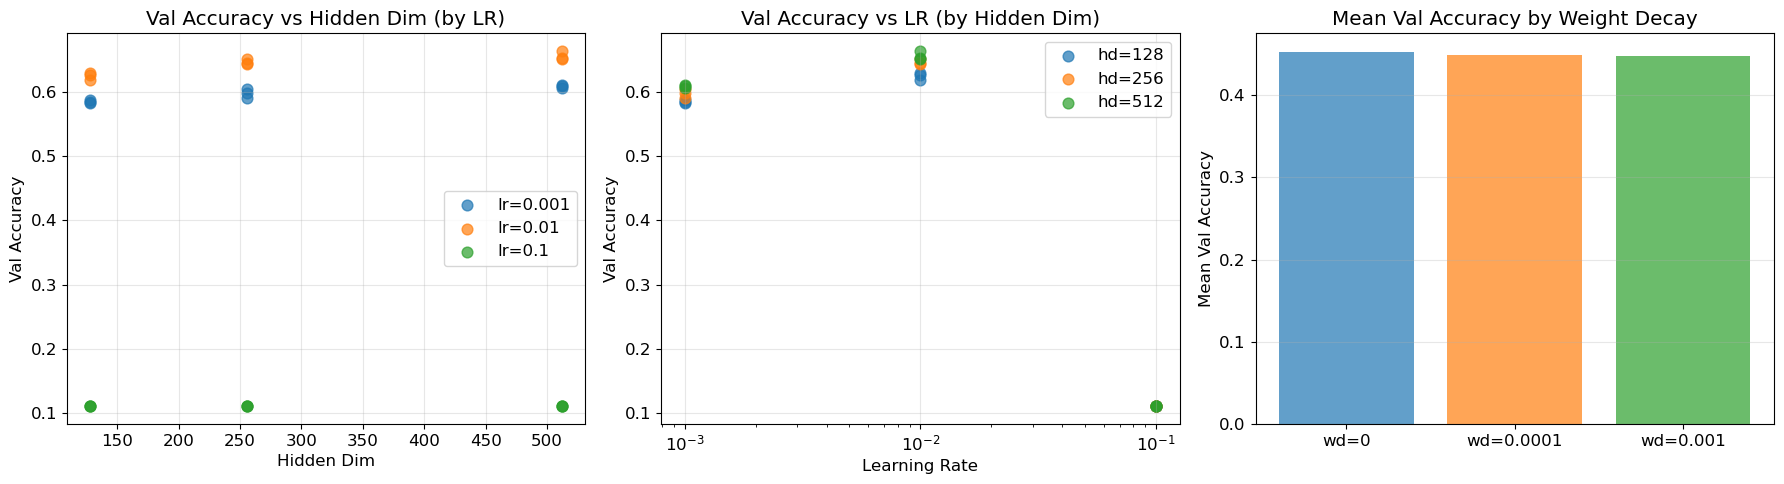

超参数搜索结果图已保存为 hyperparam_search.png


In [ ]:
def plot_search_results(results):
    """可视化超参数搜索结果"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 按学习率分组
    for lr in sorted(set(r['lr'] for r in results)):
        subset = [r for r in results if r['lr'] == lr]
        hds = [r['hidden_dim'] for r in subset]
        accs = [r['val_acc'] for r in subset]
        axes[0].scatter(hds, accs, label=f'lr={lr}', s=60, alpha=0.7)
    axes[0].set_xlabel('Hidden Dim')
    axes[0].set_ylabel('Val Accuracy')
    axes[0].set_title('Val Accuracy vs Hidden Dim (by LR)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 按隐藏层大小分组
    for hd in sorted(set(r['hidden_dim'] for r in results)):
        subset = [r for r in results if r['hidden_dim'] == hd]
        lrs = [r['lr'] for r in subset]
        accs = [r['val_acc'] for r in subset]
        axes[1].scatter(lrs, accs, label=f'hd={hd}', s=60, alpha=0.7)
    axes[1].set_xlabel('Learning Rate')
    axes[1].set_ylabel('Val Accuracy')
    axes[1].set_title('Val Accuracy vs LR (by Hidden Dim)')
    axes[1].set_xscale('log')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 按正则化强度分组
    for wd in sorted(set(r['weight_decay'] for r in results)):
        subset = [r for r in results if r['weight_decay'] == wd]
        accs = [r['val_acc'] for r in subset]
        axes[2].bar([f"wd={wd}"], [np.mean(accs)], alpha=0.7, label=f'wd={wd}')
    axes[2].set_ylabel('Mean Val Accuracy')
    axes[2].set_title('Mean Val Accuracy by Weight Decay')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('hyperparam_search.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("超参数搜索结果图已保存为 hyperparam_search.png")

# 打印结果表格
print("\n超参数搜索结果汇总:")
print(f"{'LR':>8} {'Hidden':>8} {'WD':>10} {'Val Acc':>10} {'Train Acc':>10}")
print("-" * 50)
for r in sorted(results, key=lambda x: x['val_acc'], reverse=True):
    print(f"{r['lr']:>8.4f} {r['hidden_dim']:>8d} {r['weight_decay']:>10.5f} "
          f"{r['val_acc']:>10.4f} {r['train_acc']:>10.4f}")

plot_search_results(results)

使用最佳超参数重新训练: {'lr': 0.01, 'hidden_dim': 512, 'weight_decay': 0}
模型权重已保存到 best_model_final.pkl
Epoch   1/80 | LR: 0.010000 | Train Loss: 1.6455 | Val Loss: 1.3335 | Train Acc: 0.5716 | Val Acc: 0.5326 ★ 新最佳!
模型权重已保存到 best_model_final.pkl
模型权重已保存到 best_model_final.pkl
模型权重已保存到 best_model_final.pkl
Epoch   6/80 | LR: 0.010000 | Train Loss: 0.8007 | Val Loss: 1.0857 | Train Acc: 0.7581 | Val Acc: 0.6230 ★ 新最佳!
模型权重已保存到 best_model_final.pkl
Epoch  11/80 | LR: 0.010000 | Train Loss: 0.5785 | Val Loss: 1.0609 | Train Acc: 0.8149 | Val Acc: 0.6200
模型权重已保存到 best_model_final.pkl
Epoch  16/80 | LR: 0.010000 | Train Loss: 0.4469 | Val Loss: 1.0439 | Train Acc: 0.8690 | Val Acc: 0.6442
模型权重已保存到 best_model_final.pkl
模型权重已保存到 best_model_final.pkl
Epoch  21/80 | LR: 0.010000 | Train Loss: 0.3531 | Val Loss: 1.0457 | Train Acc: 0.9153 | Val Acc: 0.6578
Epoch  26/80 | LR: 0.005000 | Train Loss: 0.2476 | Val Loss: 1.0581 | Train Acc: 0.9377 | Val Acc: 0.6588
模型权重已保存到 best_model_final.pkl
Epoch  31/80 | L

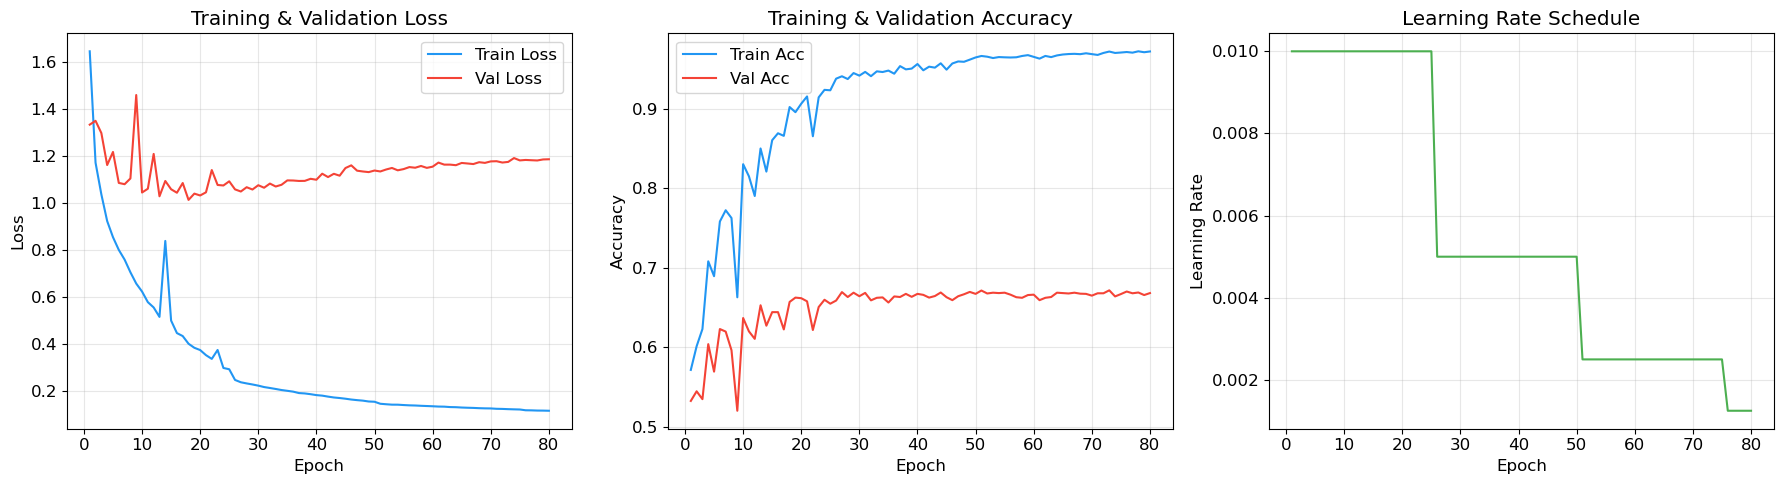

训练曲线已保存为 training_curves.png
模型权重已从 best_model_final.pkl 加载

最终测试集准确率: 0.6622


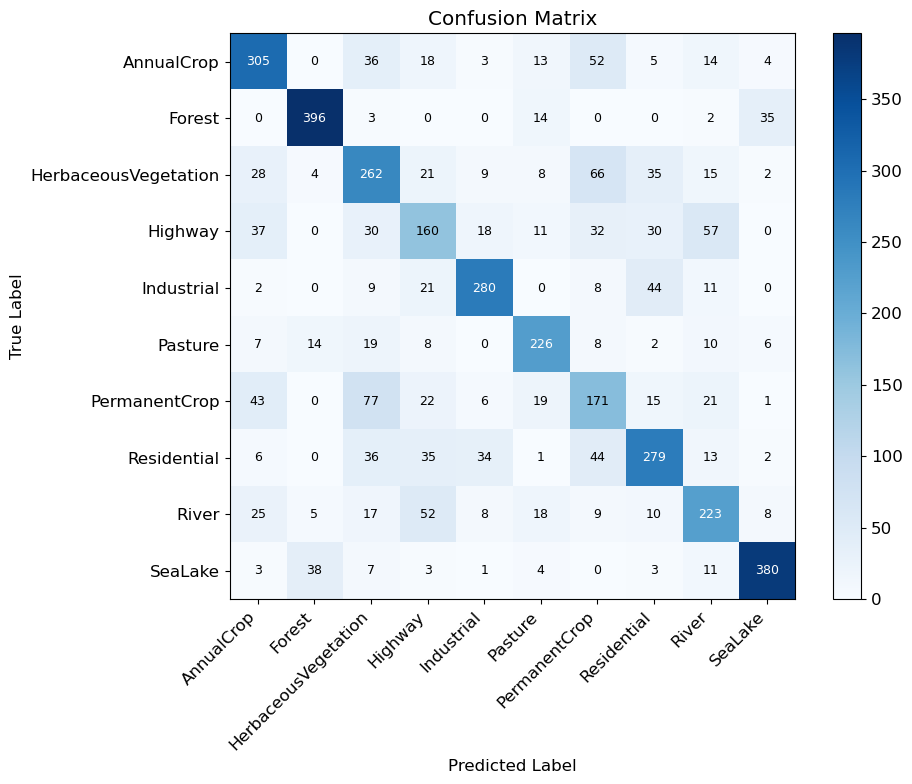

混淆矩阵已保存为 confusion_matrix.png


In [ ]:
print(f"使用最佳超参数重新训练: {best_config}")
print("=" * 60)

model_best = ThreeLayerMLP(
    input_dim=X_train.shape[1],
    hidden_dim=best_config['hidden_dim'],
    num_classes=10,
    activation='relu'
)

loss_fn_best = SoftmaxCrossEntropyLoss()
opt_best = SGDOptimizer(model_best, lr=best_config['lr'],
                        weight_decay=best_config['weight_decay'])
sch_best = LRScheduler(opt_best, strategy='step', step_size=25, gamma=0.5, total_epochs=80)
trainer_best = Trainer(model_best, opt_best, sch_best, loss_fn_best,
                       save_path='best_model_final.pkl')

history_best = trainer_best.train(X_train, y_train, X_val, y_val,
                                  epochs=80, batch_size=128)

# 绘制最佳模型的训练曲线
plot_training_curves(history_best)

# 在测试集上评估
final_model = ThreeLayerMLP.load_weights('best_model_final.pkl')
y_pred_final = final_model.predict(X_test)
test_acc_final = (y_pred_final == y_test).mean()
print(f"\n最终测试集准确率: {test_acc_final:.4f}")

cm_final = compute_confusion_matrix(y_test, y_pred_final, 10)
plot_confusion_matrix(cm_final, EuroSATDataLoader.CLASS_NAMES)